# Diabetes Dataset: Linear Regression Modeling

This notebook fits linear regression models predicting the diabetes Outcome from Glucose and BMI (and Glucose alone), using both scikit-learn/statsmodels OLS summaries and residual/error diagnostics.

In [23]:
# Import the plotting, modeling, and evaluation libraries used below
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
from statsmodels.tools.eval_measures import mse, rmse
import seaborn as sns
pd.options.display.float_format = '{:.5f}'.format
import warnings
import math
import scipy.stats as stats
import scipy
from sklearn.preprocessing import scale
warnings.filterwarnings('ignore')

In [24]:
# Load the diabetes dataset and preview the first rows
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60000,0.62700,50,1
1,1,85,66,29,0,26.60000,0.35100,31,0
2,8,183,64,0,0,23.30000,0.67200,32,1
3,1,89,66,23,94,28.10000,0.16700,21,0
4,0,137,40,35,168,43.10000,2.28800,33,1


In [1]:
# Correlation heatmap across all numeric features
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
df_kor = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(df_kor, vmin=-1, vmax=1, cmap="viridis", annot=True, linewidth=0.1)

NameError: name 'df' is not defined

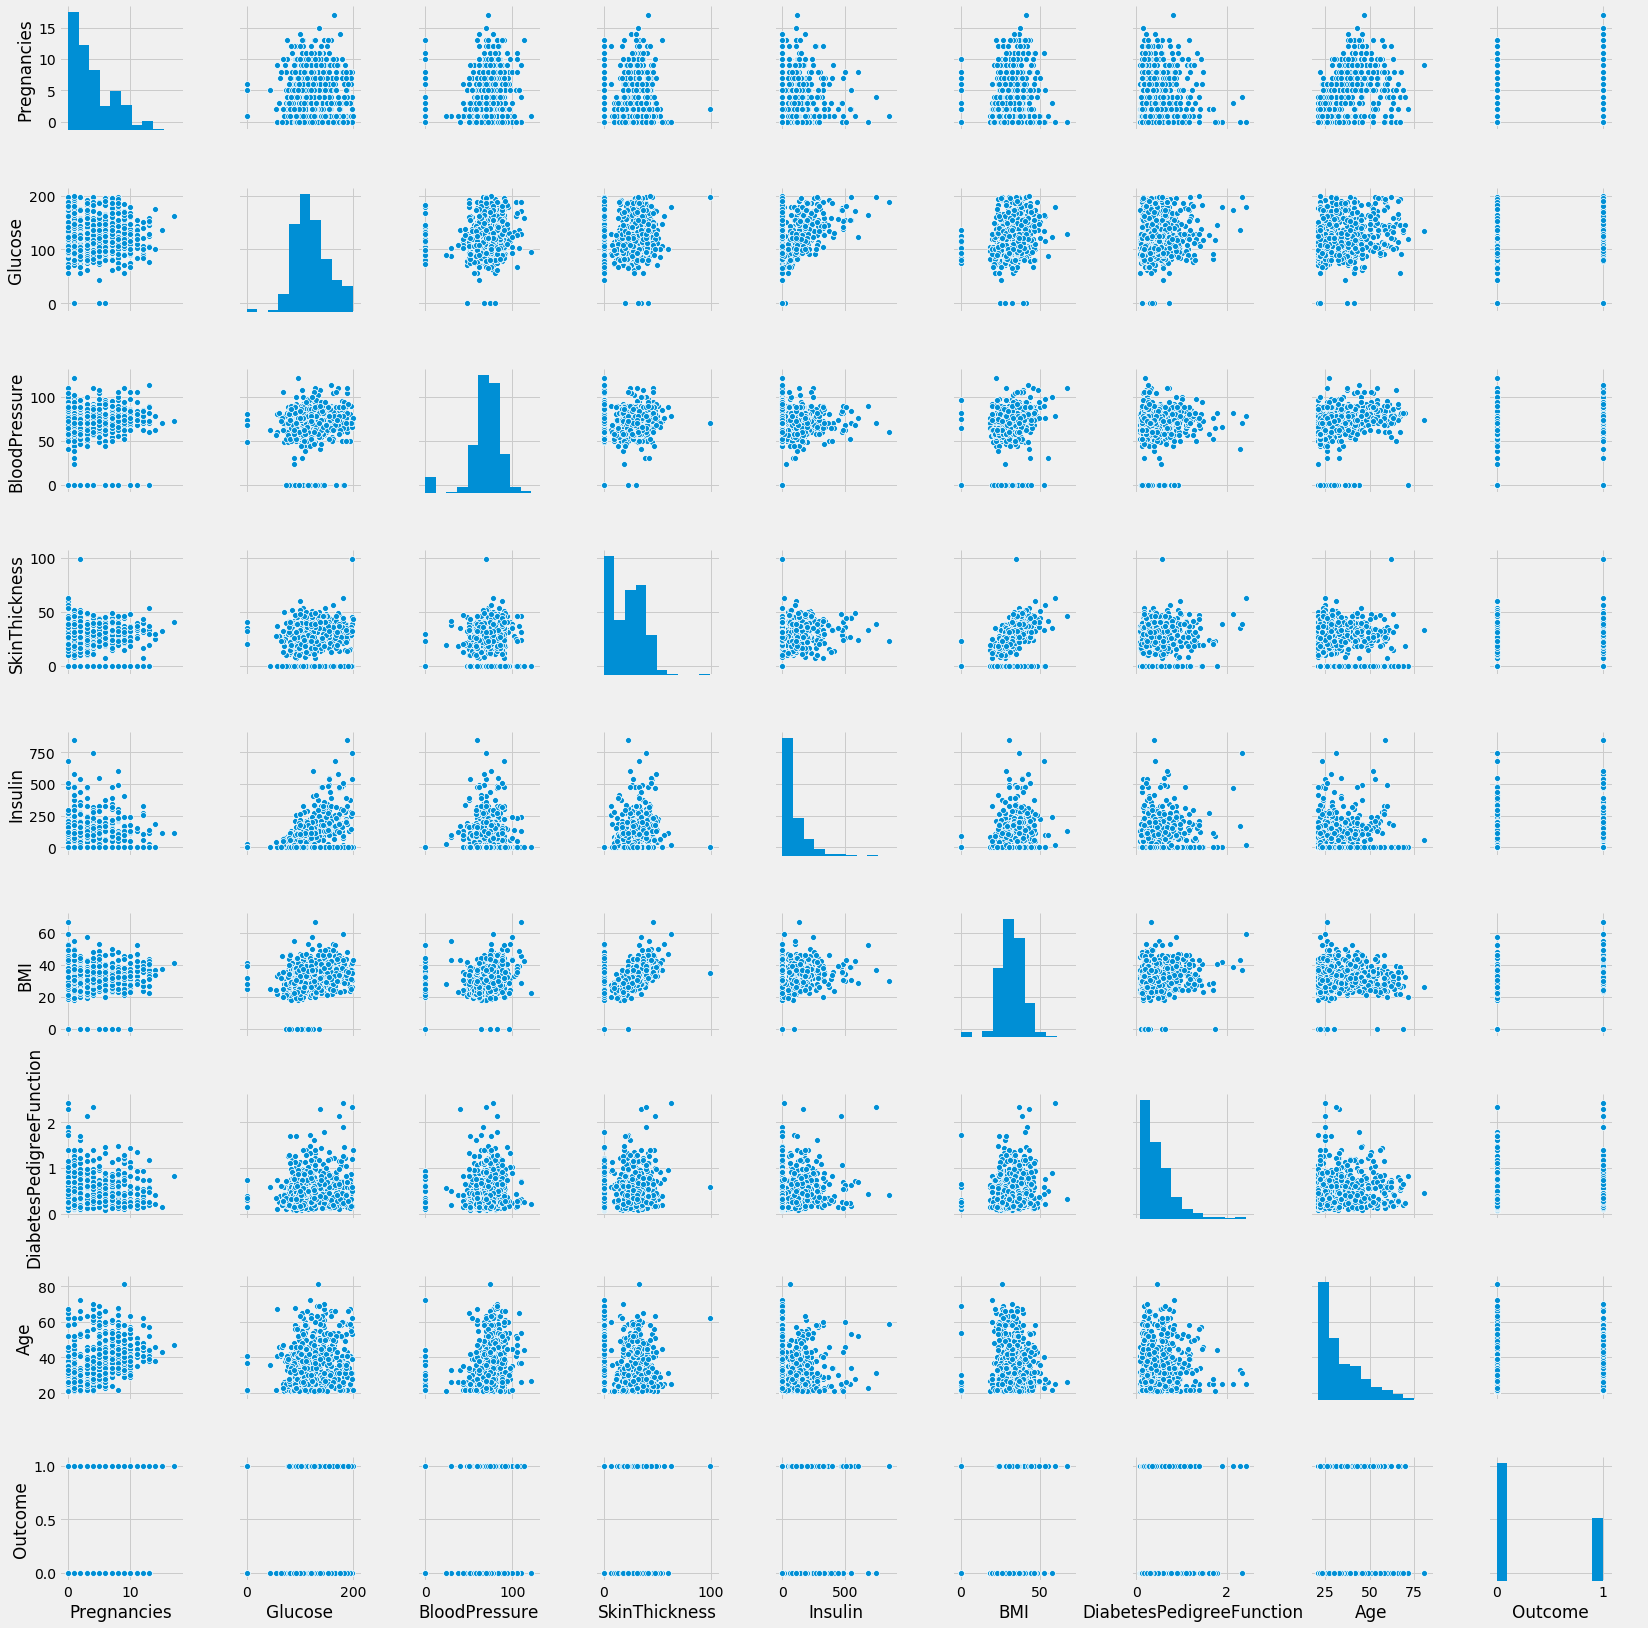

In [26]:
# Pairwise scatterplots between all numeric features
sns.pairplot(df)

In [29]:
# Check for missing values, then remove biologically invalid zero readings
# (Glucose, BloodPressure, BMI) into a separate cleaned dataframe
df.isnull().sum()
da=pd.read_csv('diabetes.csv')
da.drop( da[ da['Glucose'] == 0 ].index , inplace=True)
da.drop( da[ da['BloodPressure'] == 0 ].index , inplace=True)
da.drop( da[ da['BMI'] == 0 ].index , inplace=True)

In [36]:
# Select Glucose and BMI as predictors of the diabetes Outcome
y=df["Outcome"]

X=df[["Glucose","BMI"]]

In [58]:
# Split the data into train/test sets (80% / 20%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 465)

print('Training Data Count: {}'.format(X_train.shape[0]))
print('Testing Data Count: {}'.format(X_test.shape[0]))

Training Data Count: 614
Testing Data Count: 154


In [59]:
# Fit an OLS linear regression model and print its summary
X_train = sm.add_constant(X_train)
results = sm.OLS(y_train, X_train).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Outcome   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     106.1
Date:                Sun, 10 May 2020   Prob (F-statistic):           2.80e-40
Time:                        06:27:13   Log-Likelihood:                -324.56
No. Observations:                 614   AIC:                             655.1
Df Residuals:                     611   BIC:                             668.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8201      0.085     -9.682      0.000      -0.986      -0.654
Glucose        0.0061      0.001     11.311      0.000       0.005       0.007
BMI            0.0138      0.002      6.380      0.000       0.010       0.018
==============================================================================
Omnibus:                       52.854   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.828
Skew:                           0.487   Prob(JB):                     1.01e-08
Kurtosis:                       2.299   Cond. No.                         654.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [66]:
# Repeat the split/fit with the same two predictors
# (X2 and Y are reused from the surrounding exploratory work)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, Y, test_size = 0.2, random_state = 465)
y2=df["Outcome"]
X2=df[[ "Glucose","BMI"]]
print('Training Data Count:', X2_train.shape[0])
print('Testing Data Count::', X2_test.shape[0])


X2_train = sm.add_constant(X2_train)

results2 = sm.OLS(y2_train, X2_train).fit()
results2.summary()


Training Data Count: 614
Testing Data Count:: 154


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Outcome   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     37.31
Date:                Sun, 10 May 2020   Prob (F-statistic):           1.73e-43
Time:                        06:31:54   Log-Likelihood:                -306.07
No. Observations:                 614   AIC:                             628.1
Df Residuals:                     606   BIC:                             663.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.8306      0.092     -9.052      0.000      -1.011      -0.650
Pregnancies                  0.0241      0.005      4.953      0.000       0.015       0.034
Glucose                      0.0055      0.001      9.500      0.000       0.004       0.007
BloodPressure               -0.0017      0.001     -1.859      0.064      -0.003    9.46e-05
SkinThickness               -0.0011      0.001     -0.822      0.412      -0.004       0.001
Insulin                  -4.578e-06      0.000     -0.027      0.978      -0.000       0.000
BMI                          0.0153      0.002      6.431      0.000       0.011       0.020
DiabetesPedigreeFunction     0.1587      0.049      3.239      0.001       0.062       0.255
==============================================================================
Omnibus:                       33.773   Durbin-Watson:                   1.947
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               25.151
Skew:                           0.395   Prob(JB):                     3.46e-06
Kurtosis:                       2.400   Cond. No.                     1.04e+03
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

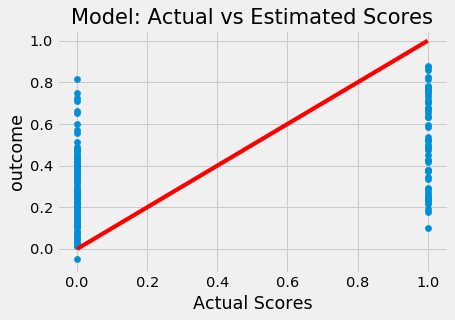

Mean Absolute Error (MAE)         : 0.3555696352836712
Mean Squared Error (MSE) : 0.16984001429029086
Root Mean Squared Error (RMSE) : 0.4121165057241591
Root Mean Squared Error (RMSE) : 0.4121165057241591
Mean Absolute Perc. Error (MAPE) : inf


In [75]:
# Plot predicted vs. actual outcome and report MAE / MSE / RMSE / MAPE
X2_test = sm.add_constant(X2_test)

y2_preds = results2.predict(X2_test)

plt.figure(dpi = 75)
plt.scatter(y2_test, y2_preds)
plt.plot(y2_test, y2_test, color="red")
plt.xlabel("Actual Scores")
plt.ylabel("outcome")
plt.title("Model: Actual vs Estimated Scores")
plt.show()
X2_test = sm.add_constant(X2_test)
y2_preds = results2.predict(X2_test)
print("Mean Absolute Error (MAE)         : {}".format(mean_absolute_error(y2_test, y2_preds)))
print("Mean Squared Error (MSE) : {}".format(mse(y2_test, y2_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y2_test, y2_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y2_test, y2_preds)))
print("Mean Absolute Perc. Error (MAPE) : {}".format(np.mean(np.abs((y2_test - y2_preds) / y2_test)) * 100))

In [72]:
# Repeat the same modeling steps using Glucose alone as the predictor
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, Y, test_size = 0.2, random_state = 465)
y2=df["Outcome"]
X2=df[[ "Glucose"]]
print('Training Data Count:', X2_train.shape[0])
print('Testing Data Count::', X2_test.shape[0])


X2_train = sm.add_constant(X2_train)

results2 = sm.OLS(y2_train, X2_train).fit()
results2.summary()


Training Data Count: 614
Testing Data Count:: 154


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Outcome   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     161.1
Date:                Sun, 10 May 2020   Prob (F-statistic):           6.28e-33
Time:                        06:35:35   Log-Likelihood:                -344.36
No. Observations:                 614   AIC:                             692.7
Df Residuals:                     612   BIC:                             701.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4726      0.067     -7.061      0.000      -0.604      -0.341
Glucose        0.0068      0.001     12.691      0.000       0.006       0.008
==============================================================================
Omnibus:                       53.300   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.128
Skew:                           0.582   Prob(JB):                     1.59e-10
Kurtosis:                       2.362   Cond. No.                         486.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

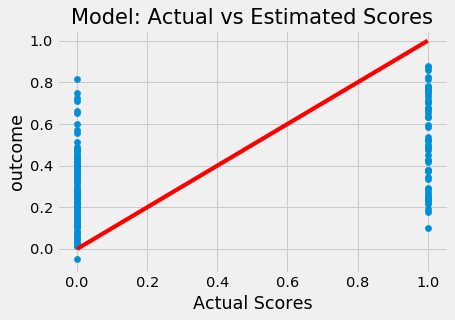

Mean Absolute Error (MAE)         : 0.3555696352836712
Mean Squared Error (MSE) : 0.16984001429029086
Root Mean Squared Error (RMSE) : 0.4121165057241591
Root Mean Squared Error (RMSE) : 0.4121165057241591
Mean Absolute Perc. Error (MAPE) : inf


In [74]:
# Plot predicted vs. actual outcome and report MAE / MSE / RMSE / MAPE
# for the single-predictor model
X2_test = sm.add_constant(X2_test)

y2_preds = results2.predict(X2_test)

plt.figure(dpi = 75)
plt.scatter(y2_test, y2_preds)
plt.plot(y2_test, y2_test, color="red")
plt.xlabel("Actual Scores")
plt.ylabel("outcome")
plt.title("Model: Actual vs Estimated Scores")
plt.show()
X2_test = sm.add_constant(X2_test)
y2_preds = results2.predict(X2_test)
print("Mean Absolute Error (MAE)         : {}".format(mean_absolute_error(y2_test, y2_preds)))
print("Mean Squared Error (MSE) : {}".format(mse(y2_test, y2_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y2_test, y2_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y2_test, y2_preds)))
print("Mean Absolute Perc. Error (MAPE) : {}".format(np.mean(np.abs((y2_test - y2_preds) / y2_test)) * 100))

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement folium.plugins (from versions: none)
ERROR: No matching distribution found for folium.plugins
